# <span style="color:rgb(213,80,0)">Import data from text file</span>

## Set up the Import Options and import the data

In [1]:
opts = delimitedTextImportOptions("NumVariables", 13);


% Specify range and delimiter
opts.DataLines = [2, Inf];
opts.Delimiter = ",";


% Specify column names and types
opts.VariableNames = ["timestamp", "machine_id", "factory_section", "temperature_sensor", "vibration_level", "motor_speed_rpm", "conveyor_status", "energy_consumption", "pressure_level", "humidity_level", "operational_hours", "machine_failure", "maintenance_needed"];
opts.VariableTypes = ["datetime", "double", "categorical", "double", "double", "double", "categorical", "double", "double", "double", "double", "double", "double"];


% Specify file level properties
opts.ExtraColumnsRule = "ignore";
opts.EmptyLineRule = "read";


% Specify variable properties
opts = setvaropts(opts, ["factory_section", "conveyor_status"], "EmptyFieldRule", "auto");
opts = setvaropts(opts, "timestamp", "InputFormat", "yyyy-MM-dd HH:mm:ss.SSS", "DatetimeFormat", "preserveinput");
opts = setvaropts(opts, "machine_id", "TrimNonNumeric", true);
opts = setvaropts(opts, "machine_id", "ThousandsSeparator", ",");


% Import the data
smart_factory = readtimetable("/MATLAB Drive/endüstriyel_akıllı_fabrika_otomasyon_dataset_2026/industrial_smart_factory_2026 (1).csv", opts, "RowTimes", "timestamp")


## Clear temporary variables

In [2]:
%clear opts


Emisyonlar türlerine göre farklı katsayılara sahiptir. Bu değerler dünya genelinde bulunan bazı kuruluşlar tarafından yayınlanır. Bazı emisyonar için ise ülkesel olarak hesaplamalar yapılır.

Fabrikada kullanılan enerjiyi karbon salınımına dönüştüreceğiz.


In [3]:
% Elektriğin katsayı değerini 0.45 kg CO2e/kWh olarak alıyoruz.
emissionFactor = 0.45;
smart_factory.scope2_emission = smart_factory.energy_consumption*emissionFactor;


% Normalizasyon
% Saatlik karbon yoğunluğuna bakalım.
% Değeri 0 olan saat satırlarından kaynaklı hataları önlemek için en düşük değeri 0.1 olarak ekliyoruz.
% bu değer olası hataları önleyecek ve aynı zamanda değerlerde büyük bir etki yaratmayacaktır.
smart_factory.carbon_intensity =smart_factory.scope2_emission ./ max(smart_factory.operational_hours,0.1);


## Bölüm Bazında Toplam Emisyon Sınıflandırması

In [4]:
hotspotReport = groupsummary(smart_factory, "factory_section", {'sum', 'mean'}, {'scope2_emission', 'carbon_intensity'});


%güncellenen tabloyu en yüksek emisyona göre sıralayalım
hotspotReport = sortrows(hotspotReport, 'sum_scope2_emission', 'descend');
disp(hotspotReport);

    factory_section    GroupCount    sum_scope2_emission    mean_scope2_emission    sum_carbon_intensity    mean_carbon_intensity
    _______________    __________    ___________________    ____________________    ____________________    _____________________
    Welding              13256           2.0385e+06                153.78                  335.31                  0.025295      
    CNC                  14104           1.5096e+06                107.03                  263.86                  0.018708      
    Robotics             13276           1.1537e+06                  86.9                  257.35                  0.019385      
    Assembly             12695           7.7539e+05                61.078                  190.19                  0.014982      
    Logistics            11830           5.7253e+05                48.396                  115.11                 0.0097304      
    Cooling_System       14225           5.1743e+05                36.375                 


sum\_scope2\_emission, fabrikada faturanın en yüksek kesildiği bölümü gösterir.

mean\_carbon\_intensity, bölümün ortalama karbon yoğunluğunu gösterir.

Toplam karbon az ancak satlik karbon yüksek görünüyorsa burada bir sorun olduğu sonucuna varılacaktır.

Bu sorunlar verimsiz çalışan, boşa enerji tüketen veya bakım gerektiren makinelerden kaynaklanıyor olabilir.

## Analizi Grafiğe Dönüştürme


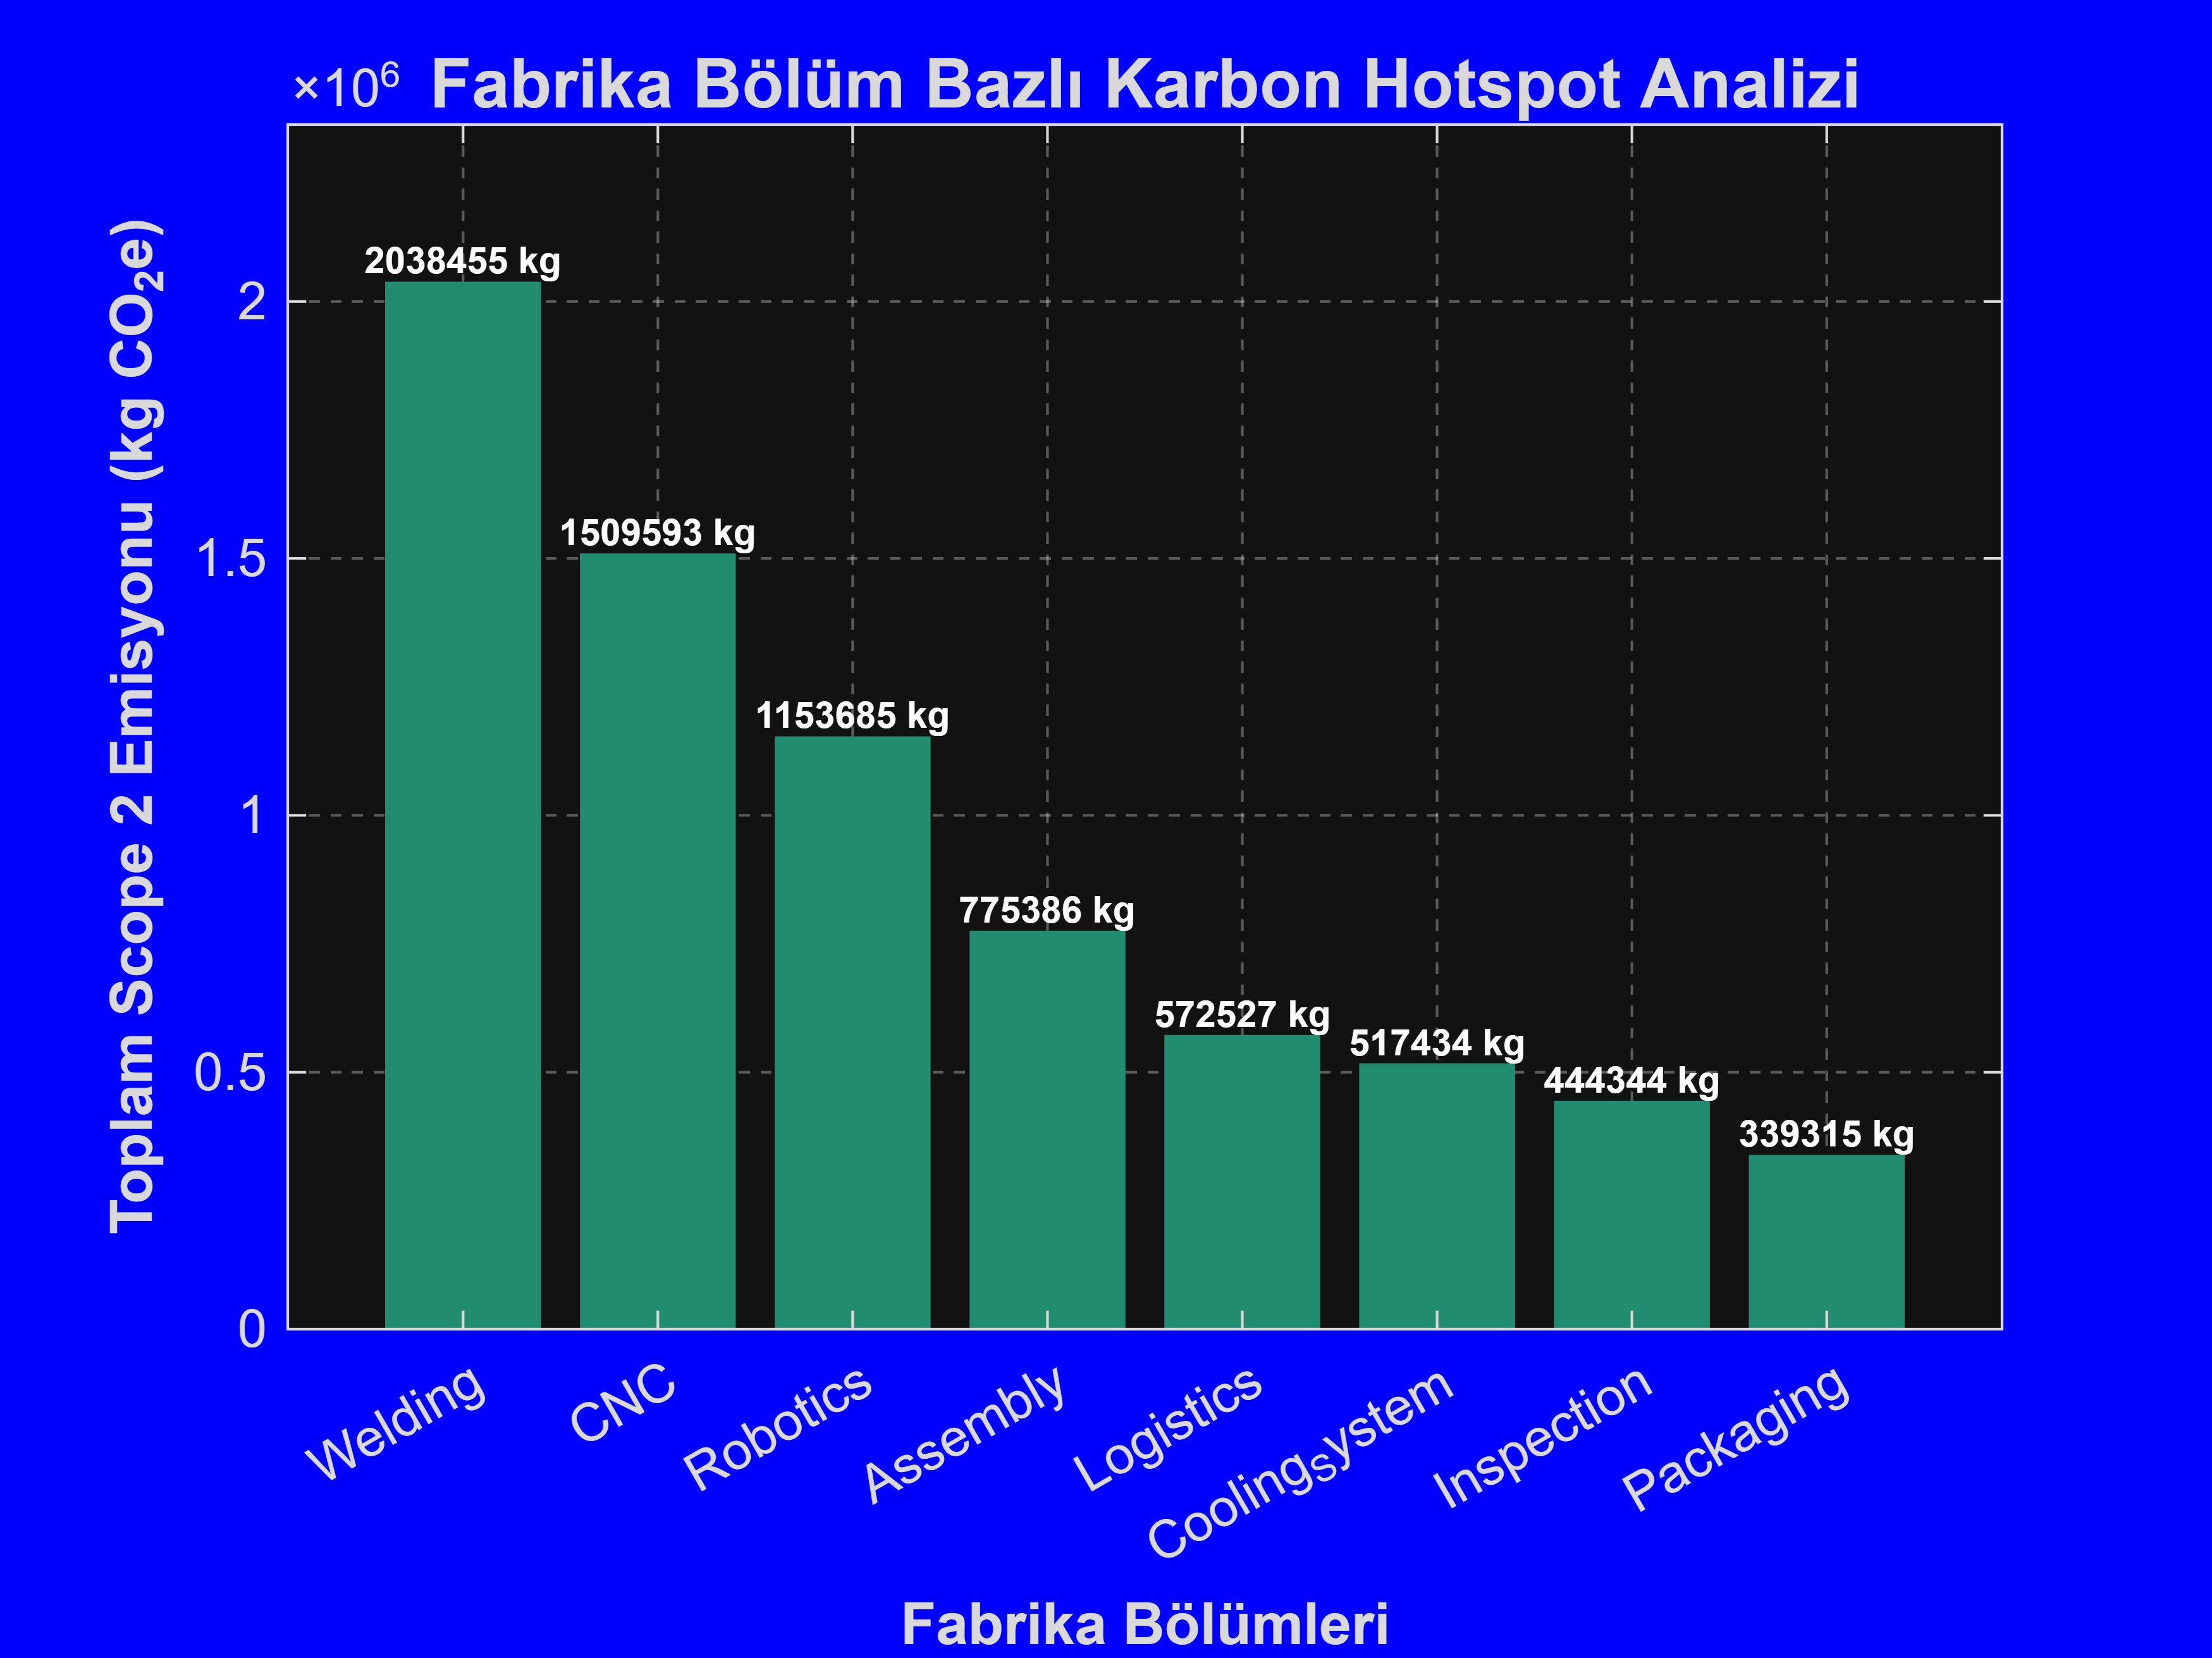

In [5]:
f = figure('Color', 'b', 'Name', 'HotSpot Analizi');
sections = categorical(hotspotReport.factory_section);
%tabloda yer aldığı sırada grafik üzerinde görüntülenmesini sağlayalım.
sections = reordercats(sections, string (hotspotReport.factory_section));


b = bar(sections, hotspotReport.sum_scope2_emission, 'FaceColor', [0.13 0.55 0.43], 'EdgeColor', 'none');


grid on;
ax = gca;
ax.GridLineStyle = '--';
ax.GridAlpha = 0.3;


ylabel('Toplam Scope 2 Emisyonu (kg CO_2e)', 'FontSize', 11, 'FontWeight', 'bold');
xlabel('Fabrika Bölümleri', 'FontSize', 11, 'FontWeight', 'bold');
title('Fabrika Bölüm Bazlı Karbon Hotspot Analizi', 'FontSize', 13, 'FontWeight', 'bold');


% çubukların üzerine değerlerini yazdıralım
xtips = b.XEndPoints;
ytips = b.YEndPoints;
grafikEtiketleri = string(round(hotspotReport.sum_scope2_emission)) + " kg";


text(xtips, ytips, grafikEtiketleri, 'HorizontalAlignment', 'center', ...
    'VerticalAlignment', 'bottom', 'FontSize', 7, 'FontWeight', 'bold', 'Color', 'w');


% Grafik sınırlarını biraz yukarı esnetelim ki etiketler yukarı taşmasın
ylim([0, max(hotspotReport.sum_scope2_emission) * 1.15]);


Fabrika içerisinde 2.0385 kg değeri ile en fazla karbon salınımı oluşturan bölüm Welding (kaynak) bölümü olarak görünüyor. Welding'i 1.5095 kg ve 1.1536 kg değerleri ile CNC ve Robotics bölümleri takip ediyor.

Karbon salınımıını azaltmak için çalışmalar geliştirilirken öncelik verilemsi gereken bölüm sık kullanılan, göz önünde olan kullanımların dışında en fazla etkiye sahip olandan başlamaktır. Çünkü bu alandaki küçük bir değişiklik diğer her şeyden daha fazla etkiye sahip olacaktır.

Welding Bölümünde neler olup bittiğini görebilmek için analzi Welding olarak özelleştireceğiz.


In [6]:
welding = smart_factory(strcmp(string(smart_factory.factory_section), 'Welding'), :);
weldingSum = groupsummary(welding, 'machine_id', {'sum', 'mean'}, ...
    {'scope2_emission', 'vibration_level', 'temperature_sensor', 'machine_failure'});
weldingSum = sortrows(weldingSum, 'sum_scope2_emission', 'descend');


disp(weldingSum);

    machine_id    GroupCount    sum_scope2_emission    mean_scope2_emission    sum_vibration_level    mean_vibration_level    sum_temperature_sensor    mean_temperature_sensor    sum_machine_failure    mean_machine_failure
    __________    __________    ___________________    ____________________    ___________________    ____________________    ______________________    _______________________    ___________________    ____________________
       -172          240               37283                  155.35                 764.51                  3.1855                   20374                     84.893                     37                    0.15417      
       -450          233               36099                  154.93                 873.66                  3.7496                   19428                     83.381                     38                    0.16309      
       -286          228               36089                  158.28                 747.82                 


## Çift Eksenli Grafik

En çok karbon üreten makineyi ve en çok arıza yapan/ titreşen makineyi göreceğiz.



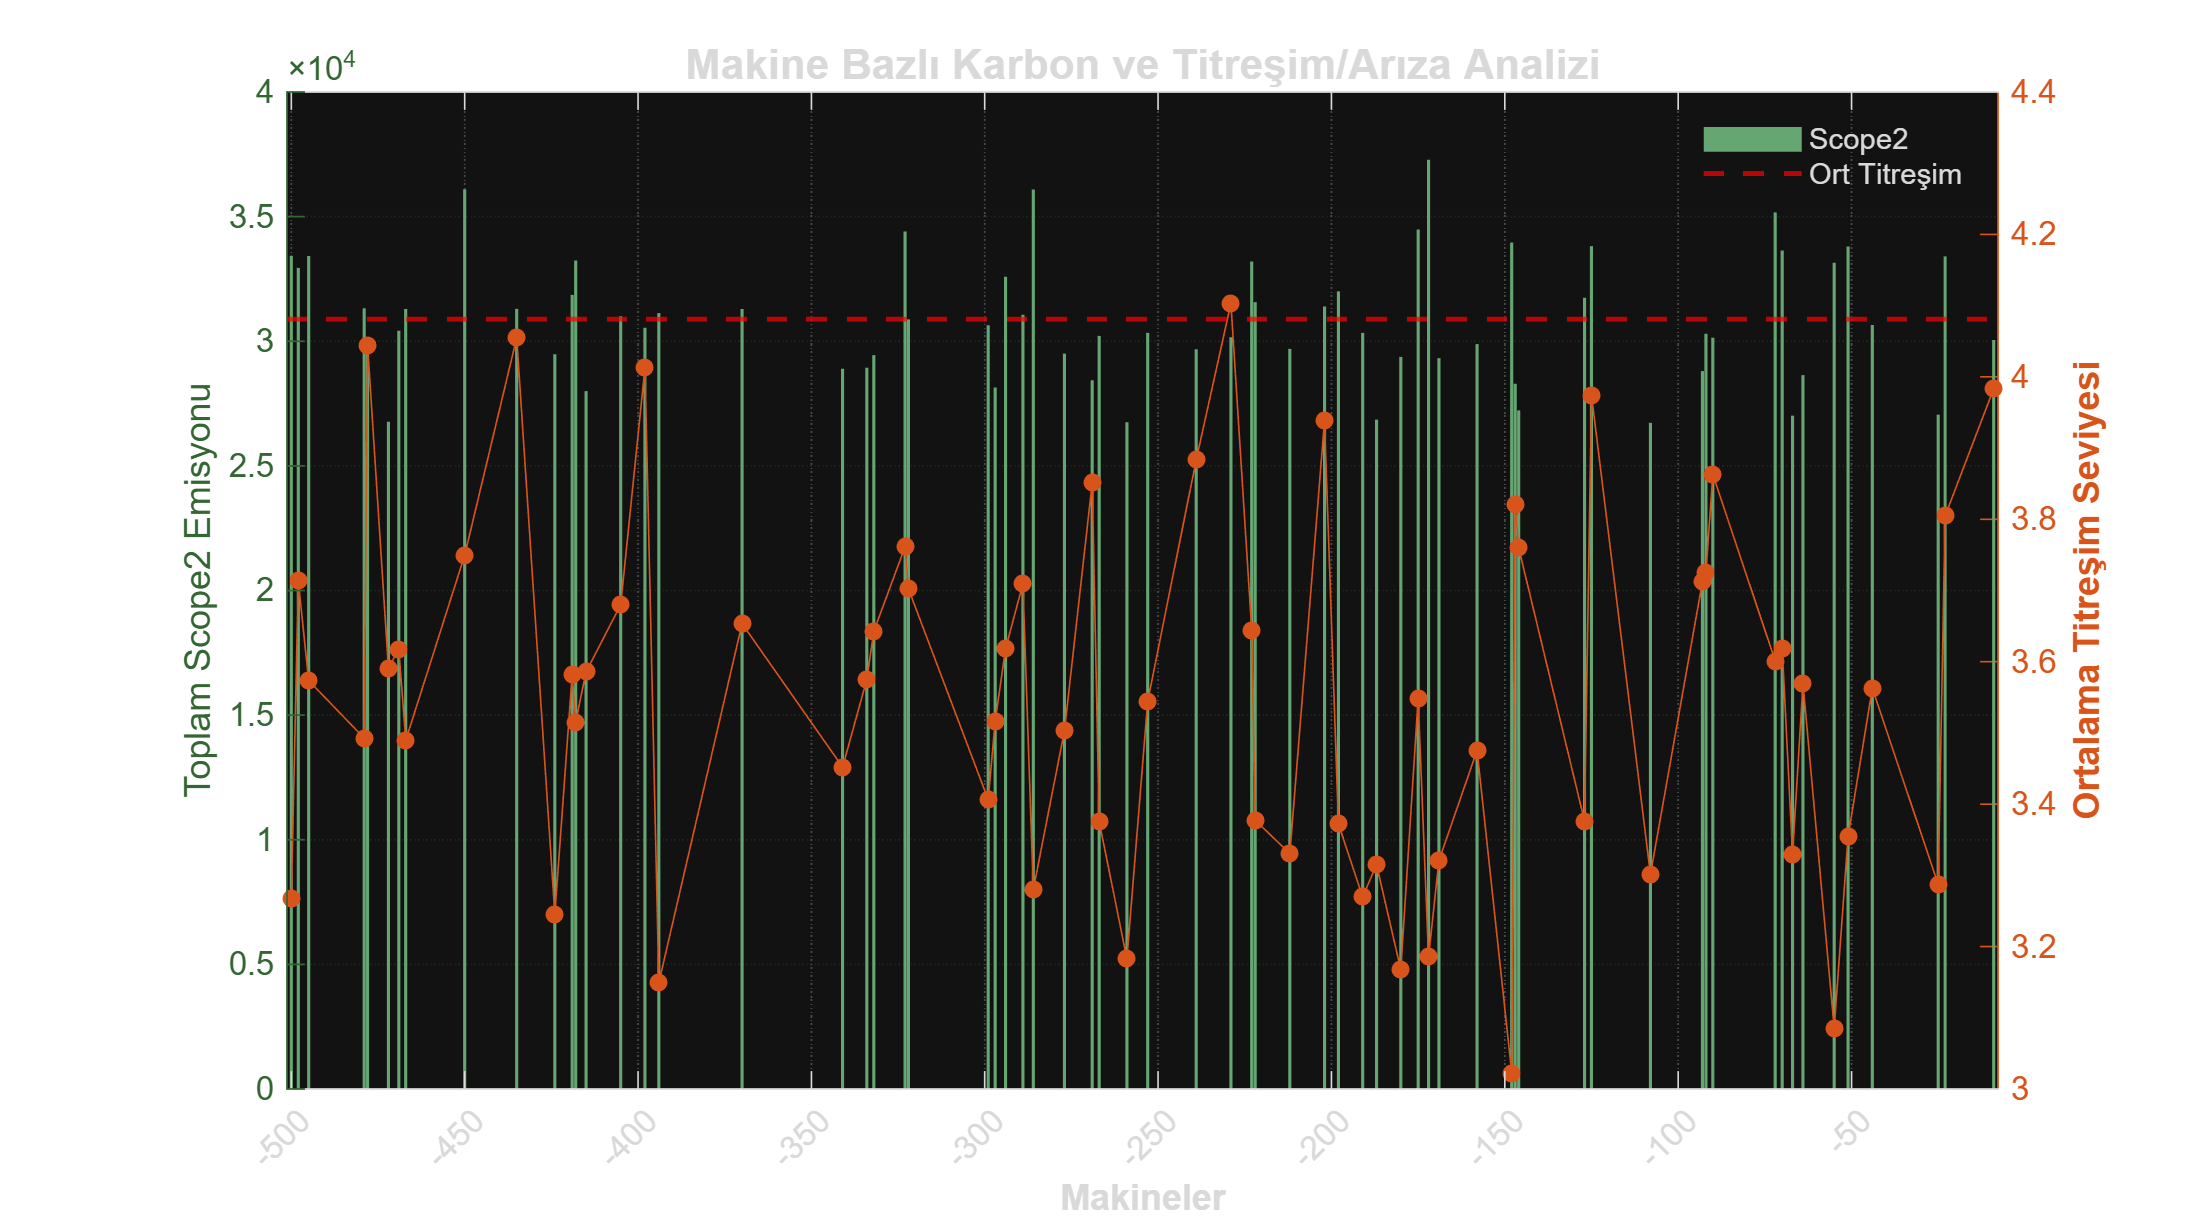

In [7]:
figure('Color', 'w', 'Position', [100 100 900 500]);
weldingSum = sortrows(weldingSum);
machines = weldingSum.machine_id;


% Sol eksen: toplam karbon emisyonu (bar chart)
yyaxis left
b = bar(machines, weldingSum.sum_scope2_emission, 0.9, 'FaceColor', [0.4 0.65 0.45], 'EdgeColor', 'none');
ylabel('Toplam Scope2 Emisyonu');
ax = gca;
ax.YColor = [0.2 0.4 0.2];


% Sağ Eksen: ortalama titreşim seviyesi (line chart)
yyaxis right
mean_vibration = double(weldingSum.mean_vibration_level);
p = plot(machines, mean_vibration, '-o', 'LineWidth', 0.5, 'Color', [0.85 0.33 0.1], 'MarkerSize', 5, 'MarkerFaceColor', [0.85 0.33 0.1]);
ylabel('Ortalama Titreşim Seviyesi', 'FontSize', 11, 'FontWeight', 'bold');
ax.YColor = [0.85 0.33 0.1];


% Genel durum görünümü
hold on;


yyaxis left
genelEmisyonOrt = mean(weldingSum.sum_scope2_emission);
yline(genelEmisyonOrt, '--', 'Color', 'r', 'LineWidth', 1.5);


xtickangle(45);


grid on;
ax.GridLineStyle = ':';
xlabel('Makineler', 'FontWeight','bold','FontSize',11);
title('Makine Bazlı Karbon ve Titreşim/Arıza Analizi', 'FontSize', 13, 'FontWeight', 'bold');


legend({'Scope2', 'Ort Titreşim'}, 'Location','northeast', 'Box','off');


hold off;